In [1]:
!pip install pandas

In [8]:
from pathlib import Path
import pandas as pd

# Step 1: Correct file path
file_path = Path(r"C:\Users\jathi\OneDrive\Desktop\PROJECT\GSE19804_series_matrix.txt.txt")

# Step 2: Read all lines safely
lines = file_path.read_text(errors='ignore').splitlines()

# Step 3: Find the header start line (contains "ID_REF")
for i, line in enumerate(lines):
    if "ID_REF" in line:
        start_line = i
        print(f"✅ Found header at line {i+1}")
        break

# Step 4: Load gene expression matrix
df = pd.read_csv(file_path, sep="\t", skiprows=start_line, low_memory=False)
df = df[df.columns.dropna()]                   # Drop empty columns
df = df.set_index("ID_REF")                    # Set gene IDs as index
df = df.loc[:, df.columns.str.startswith("GSM")]  # Keep only sample columns

# Step 5: Check data loaded
print(f"\n✅ Data loaded. Shape: {df.shape}")
df.head()

✅ Found header at line 64

✅ Data loaded. Shape: (54676, 120)


,GSM494556,GSM494557,GSM494558,GSM494559,GSM494560,GSM494561,GSM494562,GSM494563,GSM494564,GSM494565,...,GSM494666,GSM494667,GSM494668,GSM494669,GSM494670,GSM494671,GSM494672,GSM494673,GSM494674,GSM494675
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,11.96280,11.38780,11.19280,11.90360,11.75230,11.04240,10.74160,11.71090,11.46260,11.49050,...,10.35930,10.55280,10.81930,10.97170,10.38300,10.60120,11.19790,10.84320,10.60670,9.37942
1053_at,7.05652,7.33711,7.26121,7.91211,8.27448,7.60698,9.80415,8.85862,7.80342,8.43741,...,7.69447,7.80456,7.87718,7.64986,7.80042,7.92790,7.85849,7.91834,8.05853,7.51433
117_at,6.55585,6.96023,7.14488,7.13887,7.72479,8.01441,8.88544,7.99740,7.33263,10.54530,...,7.44120,7.82203,8.46291,7.68880,9.54127,8.62987,7.88748,7.85222,7.24397,8.83099
121_at,8.43850,8.51636,8.43138,8.67404,8.78145,8.55224,8.86868,8.15469,8.72485,8.13286,...,8.33440,8.18781,8.46548,8.23930,8.60798,8.59521,8.66340,8.33596,8.66742,8.46711
1255_g_at,3.73169,3.77978,3.99853,3.69171,3.93509,3.54508,4.14981,6.99991,4.38131,4.05949,...,3.73375,3.59215,3.74585,3.73324,3.65606,3.71172,3.84361,3.75038,3.87179,3.71853


In [9]:
# Step 6: Extract sample labels from metadata lines
labels = []
for line in lines:
    if line.startswith("!Sample_source_name_ch1"):
        labels = line.strip().split("\t")[1:]
        break

# Step 7: Map labels to binary (1: tumor, 0: normal)
label_map = {
    '"frozen tissue of primary tumor"': 1,
    '"frozen tissue of adjacent normal"': 0
}
y = pd.Series([label_map.get(l, -1) for l in labels], index=df.columns, name="Condition")

# Step 8: Check label distribution
print("✅ Label distribution:\n", y.value_counts())


✅ Label distribution:
 Condition
1    60
0    60
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 9a: Transpose to shape (samples x genes)
X = df.T  # shape = (120 samples × 54676 genes)
X.shape

# Step 9b: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Step 9c: Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.feature_selection import VarianceThreshold

# Step 9c.1: Remove constant features (variance = 0)
var_thresh = VarianceThreshold(threshold=0.0)
X_train_var = var_thresh.fit_transform(X_train)
X_test_var = var_thresh.transform(X_test)

# Step 9c.2: Normalize the filtered features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)


c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:112: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
c:\Users\jathi\anaconda3\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:120: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 10: Train a Random Forest model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test_scaled)

print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🧾 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



✅ Accuracy: 0.8666666666666667

🧾 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.87      0.87      0.87        15

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.87        30
weighted avg       0.87      0.87      0.87        30


📊 Confusion Matrix:
 [[13  2]
 [ 2 13]]


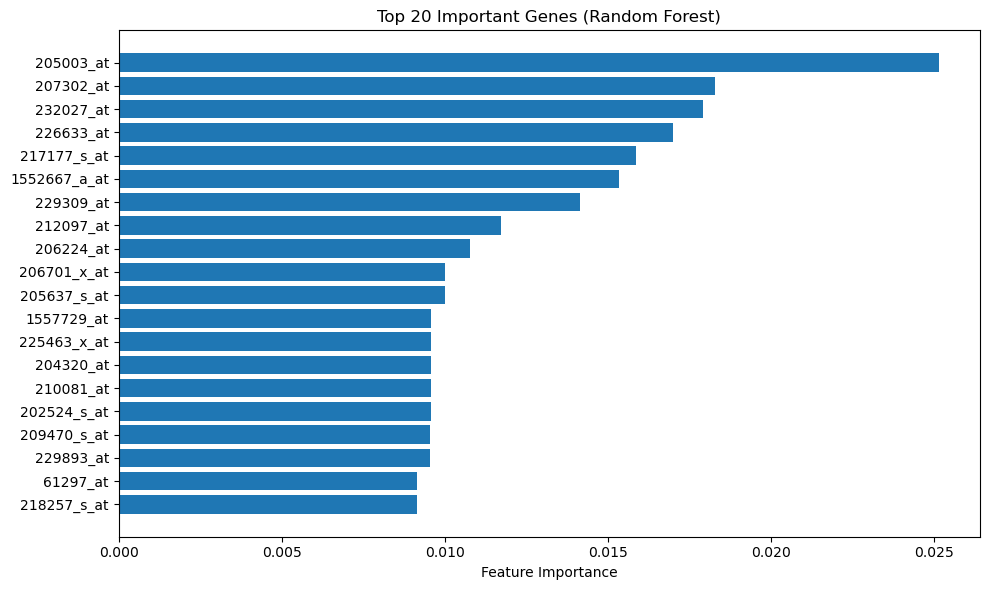

In [13]:
# Step 11: Feature Importance (top 20 genes)
import numpy as np
import matplotlib.pyplot as plt

importances = clf.feature_importances_
top_indices = np.argsort(importances)[::-1][:20]
top_genes = X.columns[top_indices]

plt.figure(figsize=(10, 6))
plt.barh(range(20), importances[top_indices][::-1], align='center')
plt.yticks(range(20), top_genes[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Important Genes (Random Forest)")
plt.tight_layout()
plt.show()


In [1]:
top_genes_df = pd.DataFrame({
    'Gene': top_genes,
    'Importance': importances[top_indices]
})
top_genes_df.to_csv("top20_genes_RF.csv", index=False)


NameError: name 'pd' is not defined

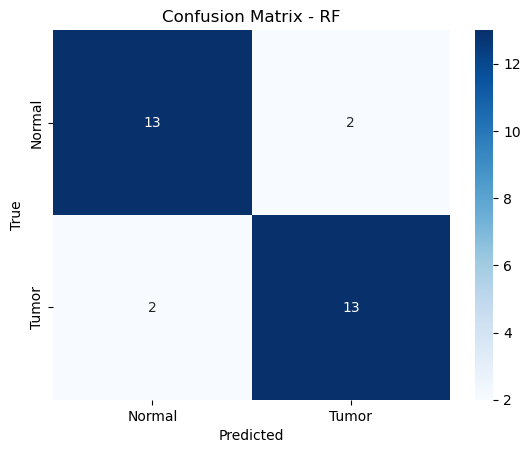

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Tumor"], yticklabels=["Normal", "Tumor"])
plt.title("Confusion Matrix - RF")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix_RF.png")
plt.show()
